Ustedes son los Ingeniros de Datos del departamento de Scouting de un equipo de élite. Estamos a mitad de la temporada 2025-2026 y nuestro jugador estrella acaba de sufrir una lesión grave. El director técnico necesita un reemplazo urgente. No tiene tiempo para ver cientos de videos; quiere que encuentren al jugador "matemáticamente más idéntico" en toda la liga.



Para la computadora, los jugadores de fútbol no son personas; son vectores flotando en un espacio multidimensional. Su misión es construir este espacio utilizando el archivo players_data-2025_2026.csv y encontrar al clon exacto de nuestra estrella.



NOTA: la descripción del dataset la podemos encontrar aquí: kaggle




Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)
Creen un Jupyter Notebook nuevo, carguen el dataset proporcionado en GitHub y seleccionen a su "Jugador Estrella" (puede ser el jugador con más goles o su favorito del dataset, la decisión es suya).

Misión:

Construyan la matriz multidimensional X seleccionando al menos 4 características numéricas (pueden ser más) continuas (float) que definan el rendimiento del jugador (por ejemplo: Goles, Asistencias, Minutos_Jugados, Precisión_Pases, Recuperaciones, etc.).

In [71]:
import pandas as pd
import numpy as np
# Instrucción: Carga tu archivo limpio. 
# Si no lo tienes a la mano, usa el siguiente bloque para descargar y pre-limpiar lo básico:

url = "datasets/players_data-2025_2026.csv"
df = pd.read_csv(url)
df.head()


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


Creen un vector para su jugador estrella y otro vector para el resto de los candidatos.

In [72]:
x = df.loc[df["Player"] == "Jude Bellingham"]
y = df.drop(df[df["Player"] == "Jude Bellingham"].index)

x = x.select_dtypes(include=[np.number])
y = y.select_dtypes(include=[np.number])

cols = [c for c in y.columns if c in x.columns]
x = x[cols].fillna(0)
y = y[cols].fillna(0)


Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.

# Se debe de escalar/normalizar

Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)
La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista.

Misión:

Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.

# La distancia es = |x1 - x2| + |y1 - y2|

In [73]:
mean = y.mean()
std = y.std().replace(0, 1)

y_scaled = (y - mean) / std
x_scaled = (x - mean) / std

y["dist_euclidiana"] = np.linalg.norm(
    y_scaled.values - x_scaled.values, ord=2, axis=1
)

y["dist_manhattan"] = np.linalg.norm(
    y_scaled.values - x_scaled.values, ord=1, axis=1
)

In [84]:
print(y["dist_manhattan"].min())
closest_player_manhattan = df.loc[y["dist_manhattan"].idxmin()]
print(y["dist_euclidiana"].min())
closest_player_euclidian = df.loc[y["dist_euclidiana"].idxmin()]

print(closest_player_euclidian)

print(closest_player_euclidian)

19.746133853887855
4.083267797097515
Rk                    745
Player        Jeremy Doku
Nation             be BEL
Pos                 MF,FW
Squad     Manchester City
               ...       
Off                     3
Crs                    62
Int                    12
TklW                   16
OG                      0
Name: 744, Length: 102, dtype: object
Rk                    745
Player        Jeremy Doku
Nation             be BEL
Pos                 MF,FW
Squad     Manchester City
               ...       
Off                     3
Crs                    62
Int                    12
TklW                   16
OG                      0
Name: 744, Length: 102, dtype: object


Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.


# Sí encontró al mismo jugador, las diferencias notables es que la distancia manhattan siempre suele ser más grande debido a que si lo ponemos en modo matemático, manhattan son el a + b de un tringulo o sus catetos y la distancia euclidiana es su hipotenusa, por lo que manhattan siempre será mayor. 

Fase 3: El Reto de Visualización en 4D (Investigación Independiente)
El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original.

El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.

Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D).

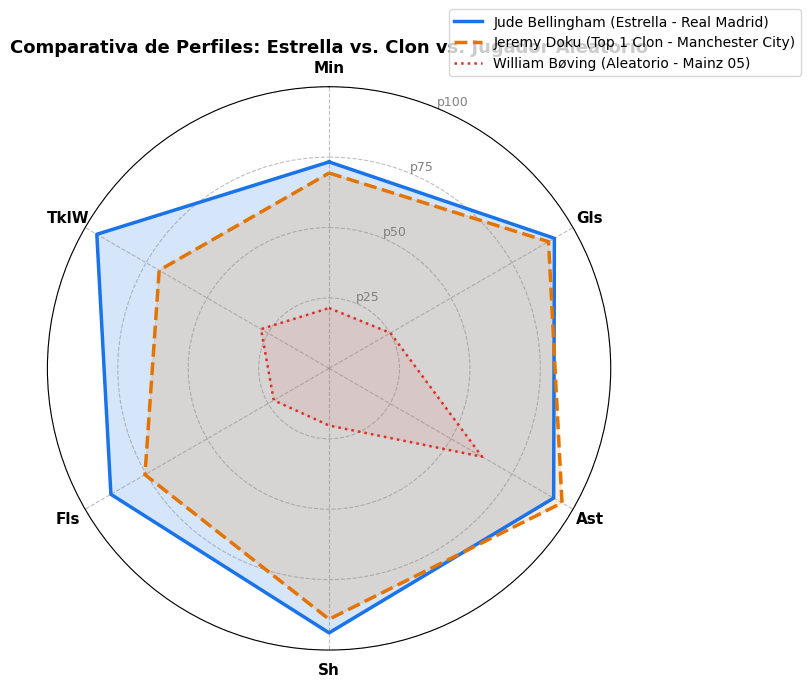

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metrics = ["Min", "Gls", "Ast", "Sh", "Fls", "TklW"]

star_idx = df[df["Player"] == "Jude Bellingham"].index[0]
clone_idx = y["dist_euclidiana"].idxmin()

pool_random = y.drop(index=[clone_idx])
random_idx = pool_random.sample(1, random_state=42).index[0]

star_label = (
    f"{df.loc[star_idx, 'Player']} (Estrella - {df.loc[star_idx, 'Squad']})"
)
clone_label = (
    f"{df.loc[clone_idx, 'Player']} (Top 1 Clon - {df.loc[clone_idx, 'Squad']})"
)
random_label = f"{df.loc[random_idx, 'Player']} (Aleatorio - {df.loc[random_idx, 'Squad']})"

pct_df = df[metrics].rank(pct=True).fillna(0) * 100

star_vals = pct_df.loc[star_idx].tolist()
clone_vals = pct_df.loc[clone_idx].tolist()
random_vals = pct_df.loc[random_idx].tolist()

star_vals += star_vals[:1]
clone_vals += clone_vals[:1]
random_vals += random_vals[:1]

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, star_vals, color="#1A73E8", linewidth=2.5, label=star_label)
ax.fill(angles, star_vals, color="#1A73E8", alpha=0.18)

ax.plot(
    angles,
    clone_vals,
    color="#E37400",
    linewidth=2.5,
    linestyle="--",
    label=clone_label,
)
ax.fill(angles, clone_vals, color="#E37400", alpha=0.15)

ax.plot(
    angles,
    random_vals,
    color="#D93025",
    linewidth=1.8,
    linestyle=":",
    label=random_label,
)
ax.fill(angles, random_vals, color="#D93025", alpha=0.08)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=11, weight="bold")
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["p25", "p50", "p75", "p100"], fontsize=9, color="gray")
ax.grid(color="gray", linestyle="--", alpha=0.5)

plt.title(
    "Comparativa de Perfiles: Estrella vs. Clon vs. Jugador Aleatorio",
    size=13,
    weight="bold",
    pad=25,
)
plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()